**ROLL NO : 24BAD087**  
**NAME : POOVIKA M**


**EXP NO : 3**

**IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION**

**PART A: DATASET PREPARATION**

In [ ]:
# STEP 1: IMPORT REQUIRED LIBRARIES

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# STEP 2: LOAD THE CIFAR-10 DATASET

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

print("Training Images:", train_images.shape)
print("Testing Images:", test_images.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1288s 8us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [3]:
# STEP 3: PREPROCESS THE IMAGES
# Normalize pixel values from 0-255 to 0-1

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

In [4]:
# STEP 4: SPLIT THE DATASET INTO TRAINING AND VALIDATION SETS

train_images, val_images, train_labels, val_labels = train_test_split(
    train_images,
    train_labels,
    test_size=0.2,
    random_state=42
)

print("Training:", train_images.shape)
print("Validation:", val_images.shape)
print("Testing:", test_images.shape)

Training: (40000, 32, 32, 3)
Validation: (10000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


**PART B: CNN MODEL IMPLEMENTATION**

In [5]:
# STEP 5: BUILD THE CNN MODEL

model = models.Sequential([

    # Convolution Layer 1 with ReLU activation
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(32,32,3)),

    # Max Pooling Layer 1
    layers.MaxPooling2D((2,2)),

    # Convolution Layer 2 with ReLU activation
    layers.Conv2D(64, (3,3), activation='relu'),

    # Max Pooling Layer 2
    layers.MaxPooling2D((2,2)),

    # Convolution Layer 3 with ReLU activation
    layers.Conv2D(64, (3,3), activation='relu'),

    # Flatten the feature maps
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),

    # Softmax Output Layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# STEP 6: DISPLAY THE CNN MODEL SUMMARY

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# STEP 7: COMPILE THE CNN MODEL

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**PART C: MODEL TRAINING AND EVALUATION**

In [8]:
# STEP 8: TRAIN THE CNN MODEL

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(val_images, val_labels)
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 50ms/step - accuracy: 0.4270 - loss: 1.5702 - val_accuracy: 0.5379 - val_loss: 1.3035
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.5801 - loss: 1.1853 - val_accuracy: 0.6138 - val_loss: 1.0902
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.6413 - loss: 1.0299 - val_accuracy: 0.6321 - val_loss: 1.0623
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.6785 - loss: 0.9209 - val_accuracy: 0.6455 - val_loss: 1.0006
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.7036 - loss: 0.8441 - val_accuracy: 0.6932 - val_loss: 0.9064
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - accuracy: 0.7258 - loss: 0.7816 - val_accuracy: 0.6980 - val_loss: 0.9056
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - accuracy: 0.7434 - loss: 0.7261 - val_accuracy: 0.7022 - val_loss: 0.8617
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 50ms/step - accuracy: 0.7603 -

In [9]:
# STEP 9: EVALUATE THE MODEL ON TEST DATA

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels
)

print("Testing Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7025 - loss: 0.9044
Testing Accuracy: 0.7024999856948853


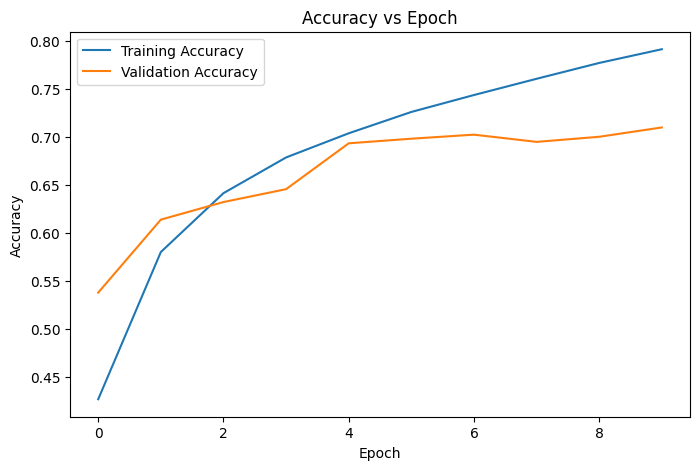

In [10]:
# STEP 10: PLOT ACCURACY VS EPOCH

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

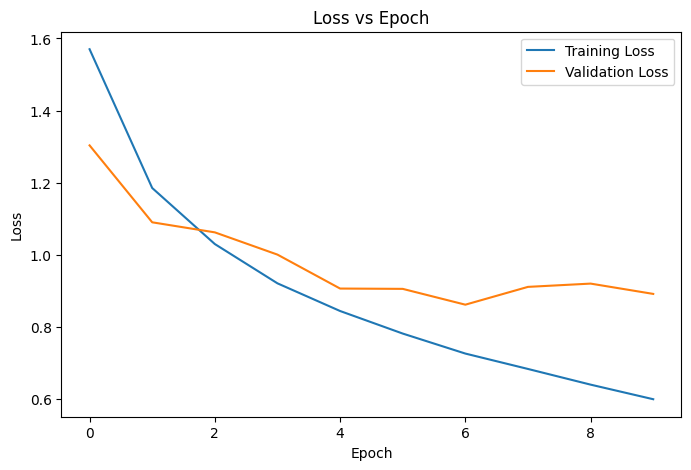

In [11]:
# STEP 11: PLOT LOSS VS EPOCH

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

**PART D: PERFORMANCE ANALYSIS**

In [12]:
# STEP 12: DISPLAY CLASSIFICATION ACCURACY

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print("Classification Accuracy: {:.2f}%".format(
    test_accuracy * 100
))

Classification Accuracy: 70.25%


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


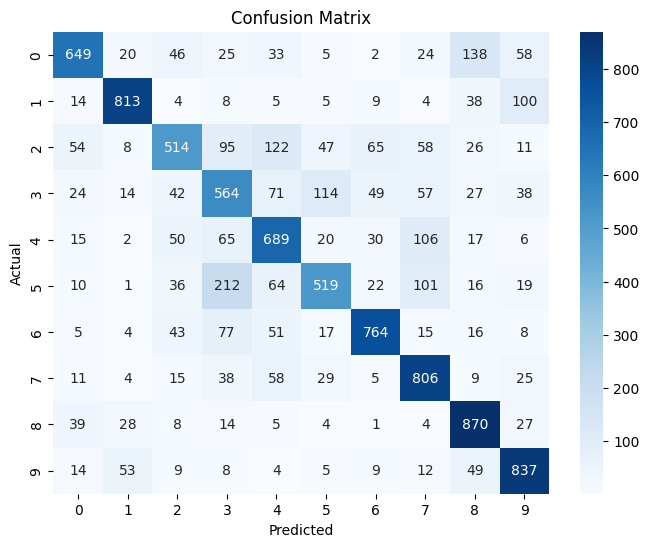

In [13]:
# STEP 13: GENERATE CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate predictions
predictions = model.predict(test_images)

# Convert probabilities to class labels
predicted_classes = np.argmax(
    predictions,
    axis=1
)

# Create confusion matrix
cm = confusion_matrix(
    test_labels.flatten(),
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

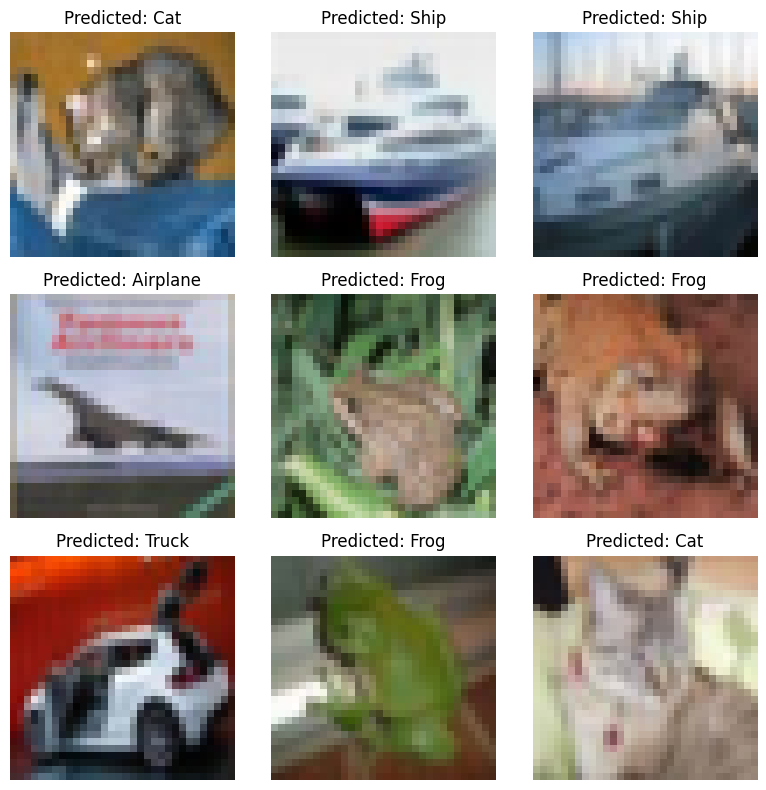

In [18]:
# STEP 14: DISPLAY SAMPLE PREDICTIONS

class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

plt.figure(figsize=(8,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(test_images[i])

    plt.title(
        "Predicted: " +
        class_names[predicted_classes[i]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

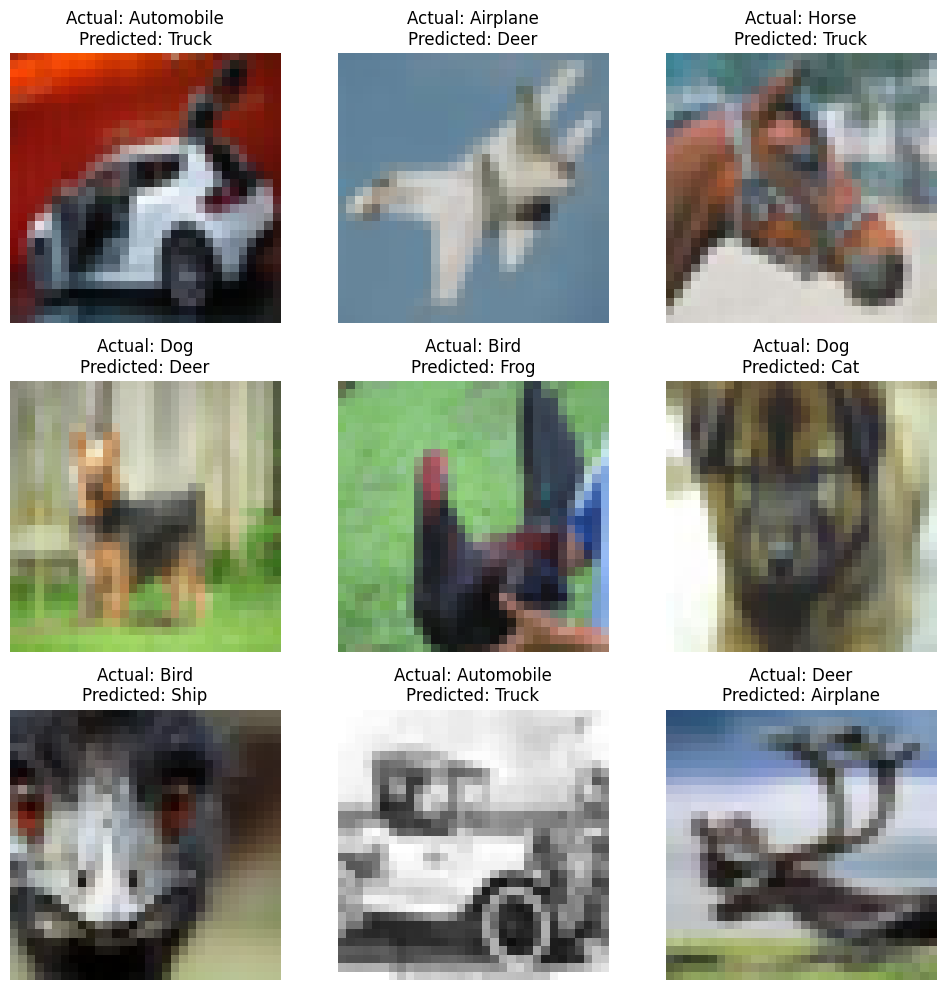

In [19]:
# STEP 15: DISPLAY MISCLASSIFIED IMAGES

misclassified = []

for i in range(len(test_labels)):

    if predicted_classes[i] != test_labels[i][0]:
        misclassified.append(i)

plt.figure(figsize=(10,10))

for j in range(9):

    idx = misclassified[j]

    plt.subplot(3,3,j+1)

    plt.imshow(test_images[idx])

    plt.title(
        f"Actual: {class_names[test_labels[idx][0]]}\n"
        f"Predicted: {class_names[predicted_classes[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# STEP 16: DISPLAY FINAL CLASSIFICATION RESULT

print("Final Test Accuracy: {:.2f}%".format(
    test_accuracy * 100
))

print("CNN model training and evaluation completed successfully.")

Final Test Accuracy: 70.25%
CNN model training and evaluation completed successfully.
